# 实验三：次梯度算法 (Subgradient Method) 探索

## 知识背景回顾

在4.2节的实验中，我们已经熟练掌握了梯度下降法。但它有一个重要的前提：函数必须是**可微**的。然而，在许多实际问题中，比如使用了L1正则项的LASSO回归，目标函数在某些点上是不可微的（存在“尖点”或“棱角”）。

为了解决这类**非光滑 (non-smooth)** 的优化问题，教材在 **4.3节** 引入了 **次梯度算法 (Subgradient Method)**。

它的核心思想是用一个**次梯度 (Subgradient)** 向量 `g` 来替代梯度 `∇f(x)`。对于凸函数，在任意点 `x` 的次梯度 `g` 都满足：
$$ f(y) \ge f(x) + g^T(y-x), \quad \forall y $$
在函数可微处，次梯度就是梯度；在不可微的“尖点”，次梯度是一个**集合**，我们从中任选一个向量即可。算法的迭代公式与梯度下降法极其相似：
$$
\mathbf{x}^{k+1} = \mathbf{x}^k - \alpha_k \mathbf{g}^k
$$
其中 $\mathbf{g}^k$ 是在 $\mathbf{x}^k$ 处**任选的一个**次梯度。

这个看似简单的改动，却带来了许多深刻而独特的性质。本次实验将带你逐一探索。

## 实验说明

本次实验将通过四个环环相扣的案例，带你深入理解次梯度算法的工作原理和关键特性。我们将全程使用一个由两个二次函数拼接而成的非光滑函数作为我们的“试验场”：
$$f(x, y) = \max \left( (x-1)^2 + (y-1)^2, \quad (x+1)^2 + (y+1)^2 \right)$$
它的不可微区域是一条直线 `y = -x`。

1.  **实验一：非光滑函数的三维可视化**
    * 我们首先将这个函数的地形用**可交互的三维曲面图**画出来。你可以用鼠标旋转、缩放来感受它的形态。我们将用**红色线条**在曲面上明确地标记出那条不可微的“山脊”（`y=-x`），让你清晰地看到两个光滑表面是如何在这里“拼接”的。

2.  **实验二：函数值 vs. 最优距离**
    * 这是本次实验的核心！我们将可视化次梯度算法的迭代过程，并同时追踪**函数值**和**与最优解的距离**的变化。你将亲眼见证该算法最“反直觉”也最关键的特性。

3.  **实验三：步长策略的“生死对决”**
    * 次梯度算法的收敛性对步长策略非常敏感。我们将对比**固定步长**和**递减步长**两种策略，观察它们对算法最终结果的决定性影响。

4.  **实验四：在“山脊”上的选择**
    * 在不可微的“山脊”上，次微分是一个**线段**集合。我们将可视化这个集合，并展示不同的次梯度选择会带来怎样不同的下一步。

In [1]:
# 导入所有需要的库
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import plotly.graph_objects as go
plt.rcParams['font.sans-serif'] = ['SimHei']  # 正确显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 正确显示负号


# --- 数据准备：定义新函数、梯度、次梯度 ---

# 两个基础的“碗”
def f1(x, y): return (x - 1)**2 + (y - 1)**2
def f2(x, y): return (x + 1)**2 + (y + 1)**2

# 最终的 max 函数
def f_new(x, y):
    return np.maximum(f1(x, y), f2(x, y))

# 两个碗的梯度
def grad_f1(x, y): return np.array([2 * (x - 1), 2 * (y - 1)])
def grad_f2(x, y): return np.array([2 * (x + 1), 2 * (y + 1)])

# 实验一使用的“有缺陷”的梯度下降法（它不知道有两个函数）
def faulty_grad_new(x, y):
    # 模拟一个“天真”的梯度下降，它只知道f2
    return grad_f2(x, y)

# 正确的次梯度函数
def subgradient_new(x, y):
    val1, val2 = f1(x, y), f2(x, y)
    if val1 > val2:
        return grad_f1(x, y)
    elif val2 > val1:
        return grad_f2(x, y)
    else: # 处在 y = -x 的“山脊”上，我们任选一个（例如f1的梯度）
        return grad_f1(x, y)

# 算法核心
def run_algorithm(grad_func, start_point, learning_rate_strategy, n_iterations):
    path = [start_point]
    point = np.array(start_point, dtype=float)
    for k in range(n_iterations):
        grad = grad_func(point[0], point[1])
        alpha = learning_rate_strategy(k) if callable(learning_rate_strategy) else learning_rate_strategy
        point = point - alpha * grad
        path.append(point.copy())
    return np.array(path)

# 绘图辅助函数
def plot_contour_and_path(ax, title, path, start_point):
    x_range = np.linspace(-3, 3, 200)
    y_range = np.linspace(-3, 3, 200)
    X, Y = np.meshgrid(x_range, y_range)
    Z = f_new(X, Y)
    
    ax.contour(X, Y, Z, levels=np.arange(0, 15, 0.75), cmap='viridis')
    # 高亮不可微区域 y = -x
    ax.plot(x_range, -x_range, 'k--', alpha=0.5, label='Non-differentiable ridge (y=-x)')
    
    ax.plot(path[:, 0], path[:, 1], '-o', color='red', markersize=3, label='Path')
    ax.plot(start_point[0], start_point[1], 'go', markersize=10, label='Start')
    ax.plot(0, 0, 'r*', markersize=15, label='Minimum')
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True)
    ax.legend()
    ax.axis('equal')


In [2]:
# --- 实验一：非光滑函数的三维可视化 ---

# 1. 生成曲面数据
x_surf = np.linspace(-3, 3, 100)
y_surf = np.linspace(-3, 3, 100)
X_surf, Y_surf = np.meshgrid(x_surf, y_surf)
Z_surf = f_new(X_surf, Y_surf)

# 2. 生成不可微“山脊”的数据 (y = -x)
x_ridge = np.linspace(-2.2, 2.2, 100)
y_ridge = -x_ridge
# 山脊的高度由任意一个函数在 y=-x 上的值决定
z_ridge = f1(x_ridge, y_ridge) 

# 3. 使用 Plotly 创建可交互的3D图
fig1 = go.Figure()

# 添加函数曲面
fig1.add_trace(go.Surface(
    z=Z_surf, x=X_surf, y=Y_surf, 
    colorscale='viridis', opacity=0.8, name='f(x,y) Surface'
))

# 添加高亮的“山脊”线
fig1.add_trace(go.Scatter3d(
    x=x_ridge, y=y_ridge, z=z_ridge,
    mode='lines',
    line=dict(color='red', width=8),
    name='Non-differentiable Ridge (y=-x)'
))

# 4. 设置图形布局
fig1.update_layout(
    title={
        'text': '实验一：非光滑函数的三维可视化', 'y':0.9, 'x':0.5
    },
    scene=dict(
        xaxis_title='x轴',
        yaxis_title='y轴',
        zaxis_title='f(x, y)'
    ),
    autosize=True,
    margin=dict(l=65, r=50, b=65, t=90)
)

fig1.show()

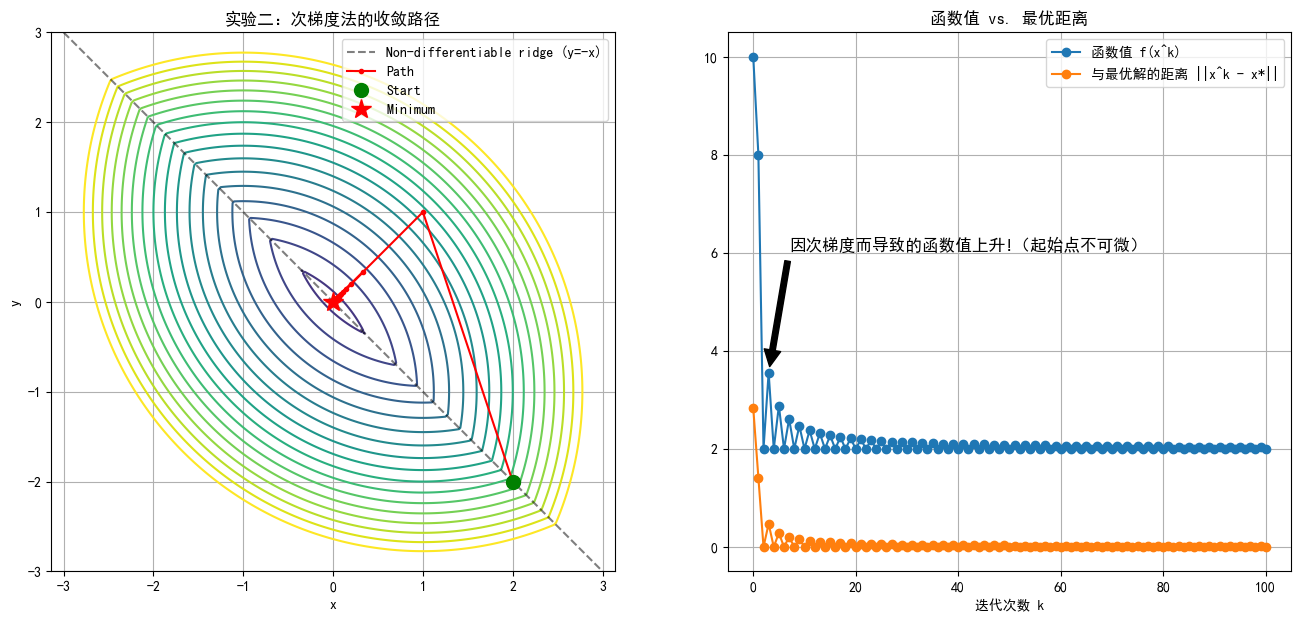

In [3]:
# --- 实验二：函数值 vs. 最优距离 ---
start_point_2 = (2.0, -2.0)
n_iter_2 = 100
path_sgm = run_algorithm(subgradient_new, start_point_2, lambda k: 0.5 / (k + 1), n_iter_2)

f_values = [f_new(p[0], p[1]) for p in path_sgm]
distances = [np.linalg.norm(p) for p in path_sgm]

fig2, (ax2_1, ax2_2) = plt.subplots(1, 2, figsize=(16, 7))
plot_contour_and_path(ax2_1, '实验二：次梯度法的收敛路径', path_sgm, start_point_2)

ax2_2.plot(range(n_iter_2 + 1), f_values, '-o', label='函数值 f(x^k)')
ax2_2.plot(range(n_iter_2 + 1), distances, '-o', label='与最优解的距离 ||x^k - x*||')
ax2_2.set_title('函数值 vs. 最优距离')
ax2_2.set_xlabel('迭代次数 k')
ax2_2.legend()
ax2_2.grid(True)

# 寻找并标记一个函数值上升的步骤
for k in range(len(f_values) - 1):
    if f_values[k+1] > f_values[k]:
        ax2_2.annotate(f'因次梯度而导致的函数值上升!（起始点不可微）', xy=(k+1, f_values[k+1]),
                     xytext=(k+5, f_values[k+1]+2.5),
                     arrowprops=dict(facecolor='black', shrink=0.05),
                     fontsize=12)
        break # 只标记第一个找到的点
plt.show()

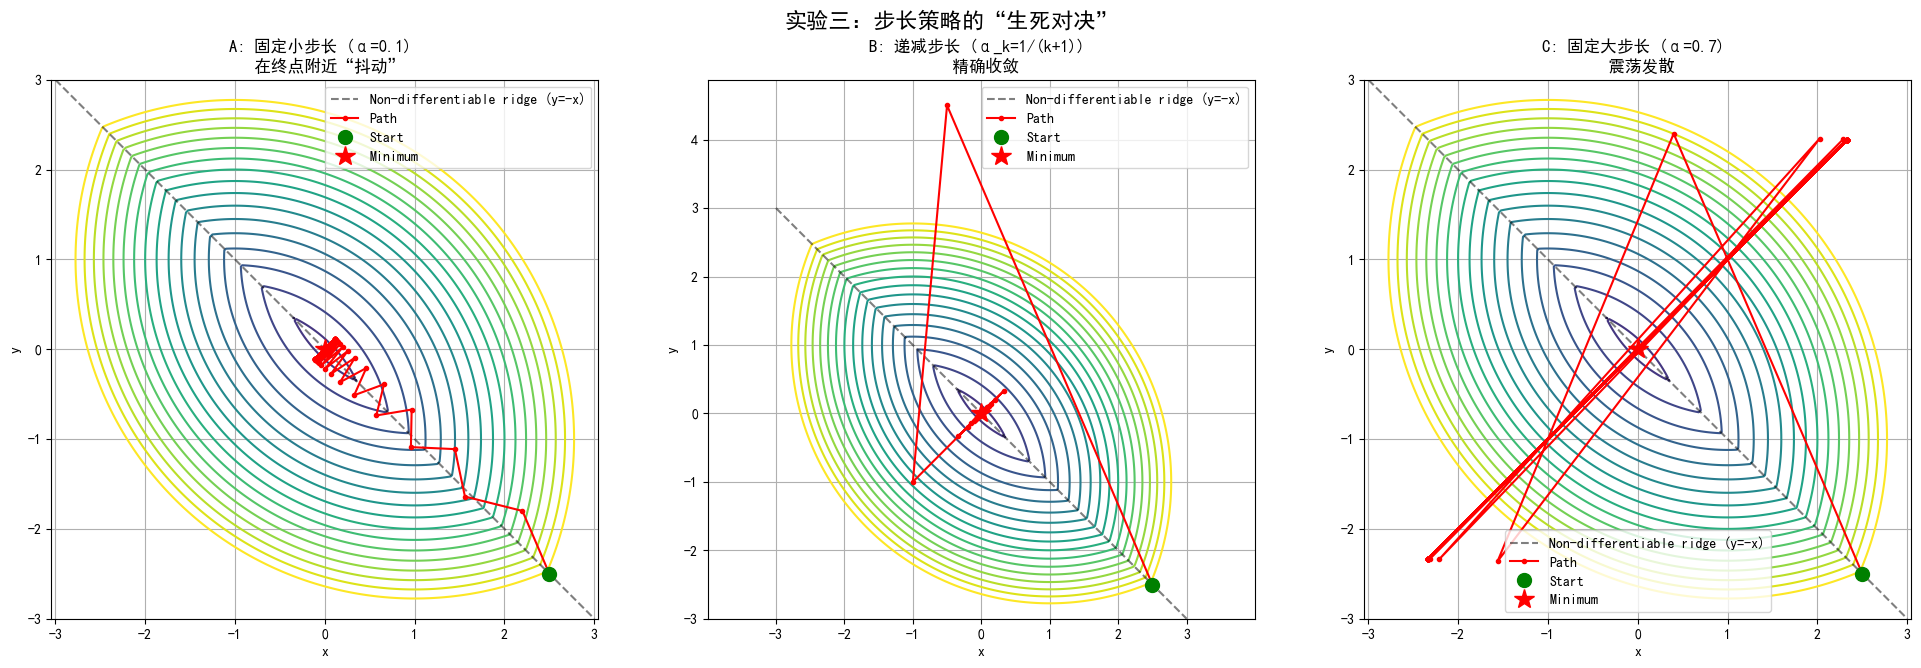

In [4]:
# --- 实验三：步长策略的“生死对决” ---
start_point_3 = (2.5, -2.5)
n_iter_3 = 50

# 三种策略
path_fixed_small = run_algorithm(subgradient_new, start_point_3, 0.1, n_iter_3)
path_diminishing = run_algorithm(subgradient_new, start_point_3, lambda k: 1.0/(k+1), n_iter_3)
path_fixed_large = run_algorithm(subgradient_new, start_point_3, 0.7, n_iter_3)

fig3, (ax3_1, ax3_2, ax3_3) = plt.subplots(1, 3, figsize=(24, 7))
fig3.suptitle('实验三：步长策略的“生死对决”', fontsize=16)
plot_contour_and_path(ax3_1, 'A: 固定小步长 (α=0.1) \n 在终点附近“抖动”', path_fixed_small, start_point_3)
plot_contour_and_path(ax3_2, 'B: 递减步长 (α_k=1/(k+1)) \n 精确收敛', path_diminishing, start_point_3)
plot_contour_and_path(ax3_3, 'C: 固定大步长 (α=0.7) \n 震荡发散', path_fixed_large, start_point_3)
plt.show()


c:\Users\Xu Yang\.conda\envs\DS\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning:

Glyph 8706 (\N{PARTIAL DIFFERENTIAL}) missing from current font.



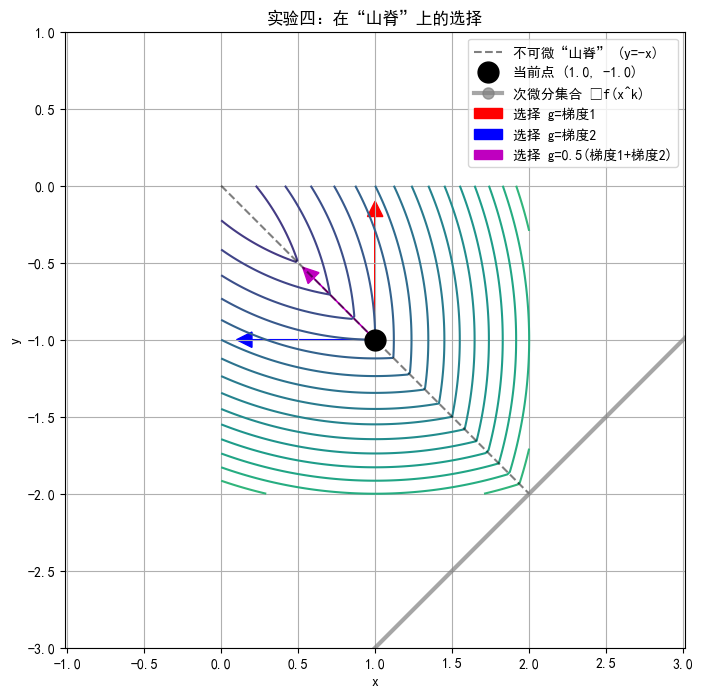

In [5]:
# --- 实验四：在“山脊”上的选择 (优化版) ---
fig4, ax4 = plt.subplots(figsize=(8, 8))
ridge_point = np.array([1.0, -1.0])

# 计算两个碗在山脊该点的梯度
grad1_at_ridge = grad_f1(ridge_point[0], ridge_point[1])
grad2_at_ridge = grad_f2(ridge_point[0], ridge_point[1])

# 选择几个次梯度
g1 = grad1_at_ridge
g2 = grad2_at_ridge
g_mid = 0.5 * g1 + 0.5 * g2

# 绘制背景
x_range_4 = np.linspace(0, 2, 100)
y_range_4 = np.linspace(-2, 0, 100)
X4, Y4 = np.meshgrid(x_range_4, y_range_4)
Z4 = f_new(X4, Y4)
ax4.contour(X4, Y4, Z4, levels=np.arange(0, 15, 0.5), cmap='viridis')
ax4.plot(x_range_4, -x_range_4, 'k--', alpha=0.5, label='不可微“山脊” (y=-x)')

# 绘制点和次微分集合
ax4.plot(ridge_point[0], ridge_point[1], 'ko', markersize=15, label=f'当前点 ({ridge_point[0]}, {ridge_point[1]})')
ax4.plot([grad1_at_ridge[0], grad2_at_ridge[0]], [grad1_at_ridge[1], grad2_at_ridge[1]], 
         'o-', color='gray', lw=3, alpha=0.7, markersize=8, label='次微分集合 ∂f(x^k)')

# 绘制不同选择带来的下一步方向
alpha_4 = 0.2
ax4.arrow(ridge_point[0], ridge_point[1], -alpha_4*g1[0], -alpha_4*g1[1], head_width=0.1, head_length=0.1, fc='r', ec='r', label='选择 g=梯度1')
ax4.arrow(ridge_point[0], ridge_point[1], -alpha_4*g2[0], -alpha_4*g2[1], head_width=0.1, head_length=0.1, fc='b', ec='b', label='选择 g=梯度2')
ax4.arrow(ridge_point[0], ridge_point[1], -alpha_4*g_mid[0], -alpha_4*g_mid[1], head_width=0.1, head_length=0.1, fc='m', ec='m', label='选择 g=0.5(梯度1+梯度2)')

ax4.set_title('实验四：在“山脊”上的选择')
ax4.set_xlabel('x'); ax4.set_ylabel('y')
ax4.grid(True); ax4.legend(); ax4.axis('equal')
ax4.set_xlim(-1, 3); ax4.set_ylim(-3, 1)
plt.show()